In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,2390,2391,2392,2393,2394,2395,2396,2397,2398,2399
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.299228
2,0.629879,0.514115,-0.293469,1.144865,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.290593,6.044705,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.866536
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-1.193043,-0.487364,-0.908142,1.116066,-0.271553,-0.376130,-0.633163,0.123939,1.031423,0.226711,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.918624
790,1.125096,1.186714,-0.128442,-0.240725,-1.569522,-0.687927,1.238028,0.160632,-1.380454,0.755241,...,-0.290593,-0.165434,0.291367,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.891481
791,-0.823325,-0.610447,-0.668821,1.034534,-0.353845,-0.572354,-0.119446,0.004899,1.136635,0.244145,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.984171
792,-0.336960,-1.640396,-0.558868,0.358328,-0.148476,0.579681,-1.060386,0.396513,-0.133678,0.005032,...,-0.290593,-0.165434,0.437196,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.059823


In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [6]:
n_components

323

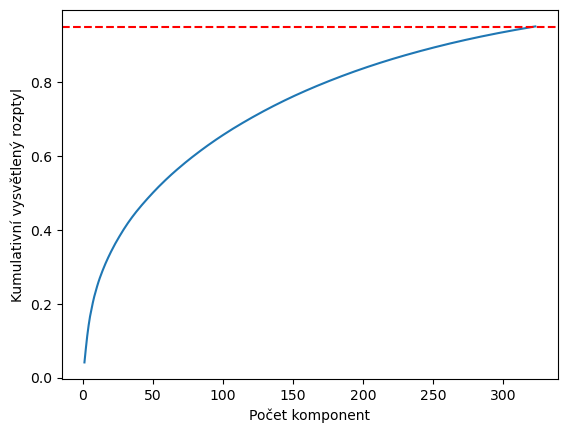

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [8]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [9]:
pred = svc.predict(X2)

In [10]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8709677419354839
Mcc: 0.5315270296169605


In [11]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid(param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],        # Regularizační parametr
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],   # Typ kernelu
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Parametr pro 'rbf', 'poly', 'sigmoid'
    'degree': [2, 3, 4, 5],                            # Relevantní pouze pro 'poly' kernel
    'coef0': [0.0, 0.1, 0.5, 1.0],                    # Relevantní pro 'poly', 'sigmoid'
    'shrinking': [True, False]                         # Použití strategie "shrinking" pro optimalizaci
}
)

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    svc = SVC(random_state=69, **param)
    svc.fit(X1, y1["Y"])
    pred_svc = svc.predict(X2)
    val_mcc.append(matthews_corrcoef(pred_svc, y2["Y"]))
    val_f1.append(f1_score(pred_svc, y2["Y"]))
    val_acc.append(accuracy_score(pred_svc, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred_svc, y2["Y"]))



  0%|                                              | 2/5376 [00:00<10:06,  8.85it/s]

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear', 'shrinking': True} 
MCC: 0.20801197866705484
Params: {'C': 0.001, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear', 'shrinking': False} 
MCC: 0.20801197866705484


  0%|                                              | 4/5376 [00:00<11:45,  7.62it/s]

Params: {'C': 0.001, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf', 'shrinking': True} 
MCC: 0.408248290463863
Params: {'C': 0.001, 'coef0': 0.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf', 'shrinking': False} 
MCC: 0.408248290463863


  0%|                                              | 6/5376 [00:00<09:24,  9.51it/s]

...

Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 0.1, 'kernel': 'sigmoid', 'shrinking': False} 
MCC: 0.11326081054134211
Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'linear', 'shrinking': True} 
MCC: 0.24618298195866545
Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'linear', 'shrinking': False} 
MCC: 0.24618298195866545
Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'rbf', 'shrinking': True} 
MCC: 0.0


100%|██████████████████████████████████████████▉| 5372/5376 [06:52<00:00, 12.91it/s]

Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'rbf', 'shrinking': False} 
MCC: 0.0
Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'poly', 'shrinking': True} 
MCC: 0.10654272078068662


100%|███████████████████████████████████████████| 5376/5376 [06:52<00:00, 13.02it/s]

Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'poly', 'shrinking': False} 
MCC: 0.10654272078068662
Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'sigmoid', 'shrinking': True} 
MCC: -0.036936356951687274
Params: {'C': 1000, 'coef0': 1.0, 'degree': 5, 'gamma': 1, 'kernel': 'sigmoid', 'shrinking': False} 
MCC: -0.036936356951687274


In [12]:
svc_res = pd.DataFrame(param_grid)

In [13]:
svc_res["mcc"] = val_mcc
svc_res["f1"] = val_f1
svc_res["acc"] = val_acc

In [14]:
svc_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [15]:
svc_res.to_csv("res/svc_res_val_1.1.csv")

In [16]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [17]:
best_params

{'shrinking': True,
 'kernel': 'rbf',
 'gamma': 'scale',
 'degree': 2,
 'coef0': 0.0,
 'C': 1}

In [18]:
svc = SVC(**best_params)
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=1, degree=2)

In [21]:
pred = svc.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8709677419354839
F1: 0.5652173913043478
Mcc: 0.5315270296169605


In [20]:
pred_test = svc.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.7926829268292683
F1: 0.2608695652173913
Mcc: 0.1905198432638073
